# 05 — Conclusões e Insights

**Objetivo:** sintetizar os principais achados do projeto, avaliar as hipóteses levantadas e comunicar os insights de forma clara e objetiva.

**Entradas:** `data/processed/dataset_analitico.csv` + resultados dos notebooks anteriores  
**Saídas:** `reports/insights_finais.md`, gráficos finais em `reports/figures/`

---

## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import statsmodels.api as sm
%matplotlib inline

from load import load_dataset
from indicators import (
    summary_by_default_periods,
    DEFAULT_PERIODS,
    pearson_correlation,
    find_extremes,
    calc_cumulative_return,
    calc_returns,
)
from plots import set_style, PALETTE, EVENTS, _save

pd.set_option('display.float_format', '{:.4f}'.format)
set_style()

df = load_dataset()
print(f'Dataset: {df.shape[0]} meses × {df.shape[1]} colunas')
print(f'Período: {df.index.min().date()} → {df.index.max().date()}')

2026-04-11 00:47:43 | INFO     | load | Dataset carregado: 175 meses × 12 colunas


Dataset: 175 meses × 12 colunas
Período: 2010-01-31 → 2024-07-31


## 1. Painel síntese — USD/BRL com todos os eventos e subperíodos

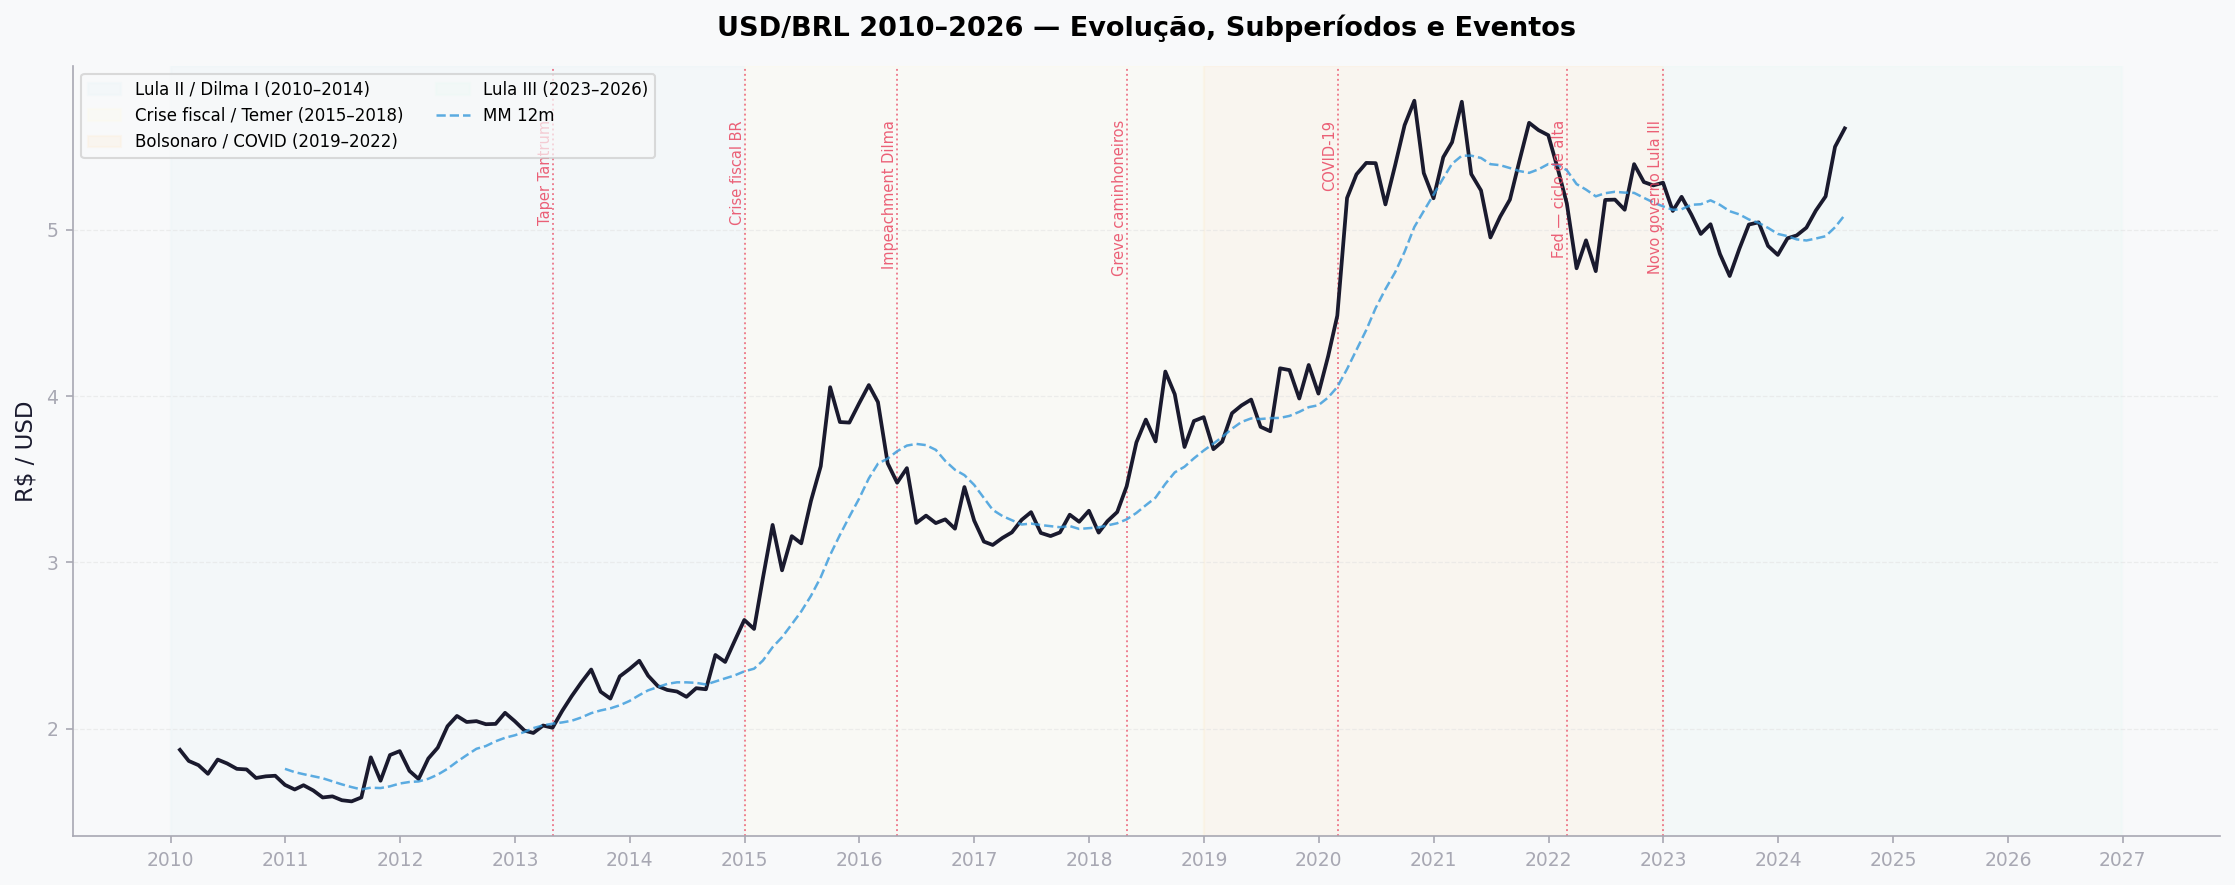

In [2]:
cores_periodos = [
    '#e8f4f8', '#fef9e7', '#fdebd0', '#e8f8f5'
]

fig, ax = plt.subplots(figsize=(15, 6))

s = df['usd_brl'].dropna()

# sombreamento por subperíodo
for (label, (ini, fim)), cor in zip(DEFAULT_PERIODS.items(), cores_periodos):
    ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fim), alpha=0.25, color=cor, label=label)

# série principal
ax.plot(s.index, s.values, color=PALETTE['primary'], linewidth=1.8, zorder=3)

# média móvel 12m
mm = s.rolling(12).mean()
ax.plot(mm.index, mm.values, color=PALETTE['neutral'],
        linewidth=1.2, linestyle='--', alpha=0.8, label='MM 12m', zorder=3)

# eventos
ymin, ymax = ax.get_ylim()
for date_str, label in EVENTS:
    date = pd.Timestamp(date_str)
    if s.index.min() <= date <= s.index.max():
        ax.axvline(date, color=PALETTE['accent'], linewidth=0.9, linestyle=':', alpha=0.7)
        ax.text(date, s.max() * 0.98, label,
                rotation=90, fontsize=7, color=PALETTE['accent'],
                va='top', ha='right', alpha=0.85)

ax.set_title('USD/BRL 2010–2026 — Evolução, Subperíodos e Eventos', fontweight='bold', fontsize=13, pad=14)
ax.set_ylabel('R$ / USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('../reports/figures/05_painel_sintese.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Avaliação das hipóteses

In [3]:
# correlações para suporte quantitativo à avaliação das hipóteses
corr = pearson_correlation(df, target='usd_brl')

hipoteses = {
    'H1 — Instabilidade política/fiscal': ['embi_brasil', 'ibovespa'],
    'H2 — Juros altos nos EUA':           ['fed_funds', 'dxy'],
    'H3 — Aversão ao risco global':       ['vix'],
    'H4 — Diferencial de juros':          ['spread_juros'],
}

print('Avaliação quantitativa das hipóteses')
print('=' * 55)
for hip, cols in hipoteses.items():
    print(f'\n{hip}')
    for col in cols:
        if col in corr.index:
            r = corr[col]
            direcao = '↑ positiva' if r > 0 else '↓ negativa'
            forca = 'forte' if abs(r) > 0.6 else ('moderada' if abs(r) > 0.3 else 'fraca')
            print(f'  {col:<25} r = {r:+.3f}  ({direcao}, {forca})')

Avaliação quantitativa das hipóteses

H1 — Instabilidade política/fiscal
  embi_brasil               r = +0.476  (↑ positiva, moderada)
  ibovespa                  r = +0.794  (↑ positiva, forte)

H2 — Juros altos nos EUA
  dxy                       r = +0.823  (↑ positiva, forte)

H3 — Aversão ao risco global
  vix                       r = +0.182  (↑ positiva, fraca)

H4 — Diferencial de juros


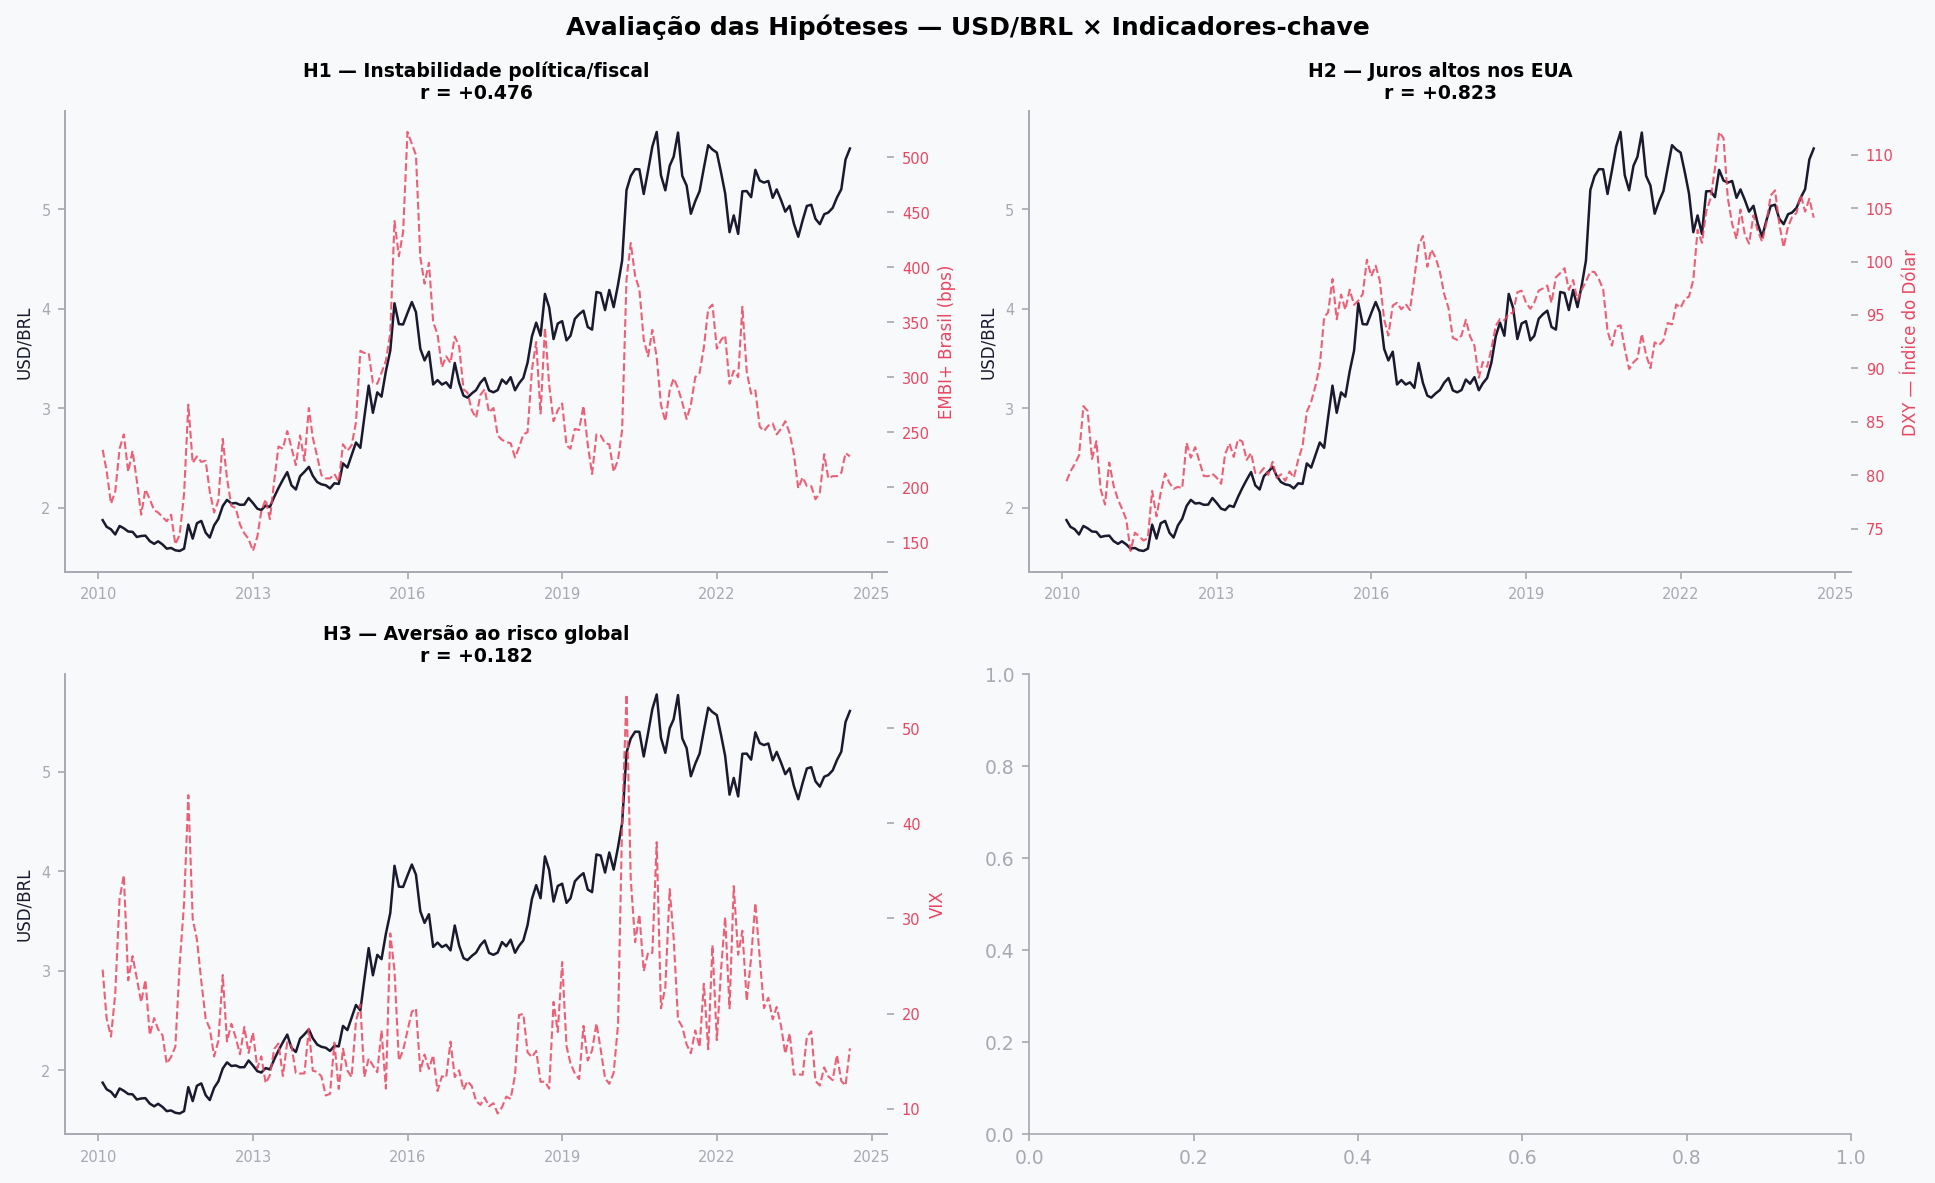

In [4]:
# painel visual de avaliação das hipóteses
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

pares_hipoteses = [
    ('embi_brasil',  'EMBI+ Brasil (bps)',   'H1 — Instabilidade política/fiscal', False),
    ('dxy',          'DXY — Índice do Dólar', 'H2 — Juros altos nos EUA',           False),
    ('vix',          'VIX',                   'H3 — Aversão ao risco global',        False),
    ('spread_juros', 'Spread Juros (p.p.)',   'H4 — Diferencial de juros',           True),
]

for i, (col, label, titulo, invert) in enumerate(pares_hipoteses):
    ax1 = axes[i]
    if col not in df.columns:
        continue
    s1 = df['usd_brl'].dropna()
    s2 = df[col].dropna()

    ax1.plot(s1.index, s1.values, color=PALETTE['primary'], linewidth=1.2)
    ax1.set_ylabel('USD/BRL', fontsize=8, color=PALETTE['primary'])
    ax1.tick_params(axis='y', labelsize=7)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.xaxis.set_major_locator(mdates.YearLocator(3))
    ax1.tick_params(axis='x', labelsize=7)
    ax1.spines[['top', 'right']].set_visible(False)

    ax2 = ax1.twinx()
    ax2.plot(s2.index, s2.values, color=PALETTE['accent'],
             linewidth=1, linestyle='--', alpha=0.85)
    ax2.set_ylabel(label, fontsize=8, color=PALETTE['accent'])
    ax2.tick_params(axis='y', labelsize=7, labelcolor=PALETTE['accent'])
    if invert:
        ax2.invert_yaxis()

    r = corr.get(col, float('nan'))
    ax1.set_title(f'{titulo}\nr = {r:+.3f}', fontsize=9, fontweight='bold')

plt.suptitle('Avaliação das Hipóteses — USD/BRL × Indicadores-chave',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/05_avaliacao_hipoteses.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Resumo estatístico por subperíodo

In [5]:
summary = summary_by_default_periods(df, 'usd_brl')
summary.round(3)

,início,fim,média,mediana,mínimo,máximo,desvio_padrão,variação_%,n_meses
período,,,,,,,,,
Lula II / Dilma I (2010–2014),2010-01-01,2014-12-31,1.9800,1.9970,1.5630,2.6540,0.2790,41.7110,60
Crise fiscal / Temer (2015–2018),2015-01-01,2018-12-31,3.4330,3.2950,2.6000,4.1490,0.3520,48.9960,48
Bolsonaro / COVID (2019–2022),2019-01-01,2022-12-31,4.9240,5.1830,3.6810,5.7780,0.6410,43.5490,48
Lula III (2023–2026),2023-01-01,2026-12-31,5.0570,5.0330,4.7230,5.6110,0.2150,9.7010,19


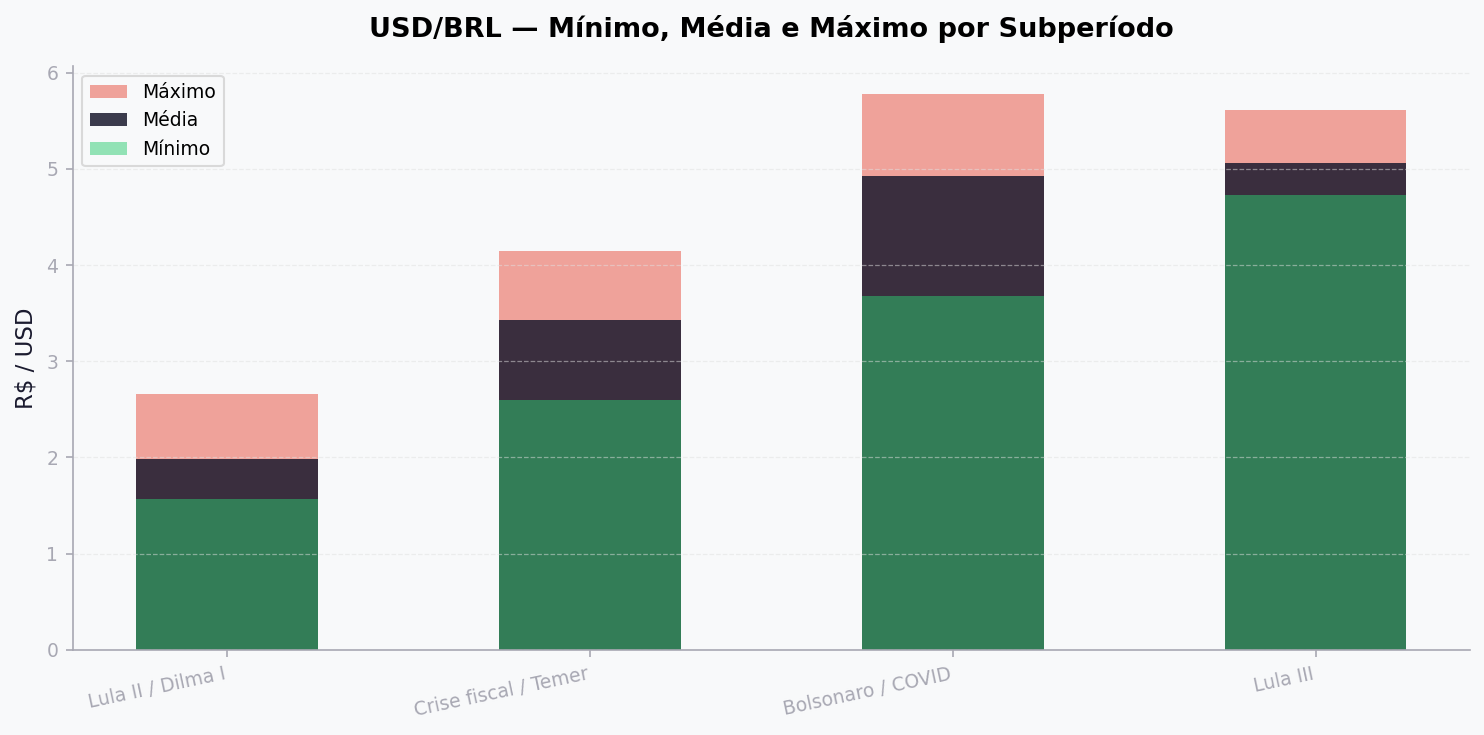

In [6]:
# gráfico de barras empilhadas: mín/máx/média por período
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(summary))
labels = [p.split('(')[0].strip() for p in summary.index]

ax.bar(x, summary['máximo'],  color=PALETTE['negative'],  alpha=0.5, label='Máximo', width=0.5)
ax.bar(x, summary['média'],   color=PALETTE['primary'],   alpha=0.85, label='Média',  width=0.5)
ax.bar(x, summary['mínimo'],  color=PALETTE['positive'],  alpha=0.5, label='Mínimo', width=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=9)
ax.set_ylabel('R$ / USD')
ax.set_title('USD/BRL — Mínimo, Média e Máximo por Subperíodo', fontweight='bold', pad=14)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/05_resumo_por_periodo.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Top eventos — impacto no câmbio

In [7]:
retornos = calc_returns(df['usd_brl'])

# maiores altas e quedas mensais
extremos_retorno = pd.concat([
    retornos.nlargest(5).rename('retorno'),
    retornos.nsmallest(5).rename('retorno')
]).sort_index()

extremos_retorno_df = extremos_retorno.reset_index()
extremos_retorno_df['retorno_%'] = (extremos_retorno_df['retorno'] * 100).round(2)
extremos_retorno_df['tipo'] = extremos_retorno_df['retorno'].apply(
    lambda v: '📈 Alta' if v > 0 else '📉 Queda'
)
extremos_retorno_df[['data', 'retorno_%', 'tipo']]

,data,retorno_%,tipo
0,2011-09-30,15.2000,📈 Alta
1,2011-10-31,-7.6900,📉 Queda
2,2015-02-28,11.7200,📈 Alta
3,2015-04-30,-8.4700,📉 Queda
4,2015-09-30,13.2900,📈 Alta
5,2016-03-31,-9.3000,📉 Queda
6,2016-06-30,-9.2400,📉 Queda
7,2018-08-31,11.2800,📈 Alta
8,2018-10-31,-7.9100,📉 Queda
9,2020-03-31,15.7800,📈 Alta


## 5. Geração do relatório de insights

In [10]:
# coleta métricas para o relatório
media_geral   = df['usd_brl'].mean()
max_historico = df['usd_brl'].max()
max_data      = df['usd_brl'].idxmax()
min_historico = df['usd_brl'].min()
min_data      = df['usd_brl'].idxmin()
depr_total    = calc_cumulative_return(retornos * 100).iloc[-1]
corr_vix      = corr.get('vix', float('nan'))
corr_embi     = corr.get('embi_brasil', float('nan'))
corr_dxy      = corr.get('dxy', float('nan'))
corr_spread   = corr.get('spread_juros', float('nan'))
corr_spread_display = (
    f'r = {corr_spread:+.3f}'
    if pd.notna(corr_spread)
    else 'sem dados no dataset'
 )

insights_md = f"""# Insights Finais — USD/BRL 2010–2026

*Gerado automaticamente em {pd.Timestamp.now().strftime('%d/%m/%Y')}*

---

## Visão geral do período

- **Média histórica:** R$ {media_geral:.4f}
- **Máxima histórica:** R$ {max_historico:.4f} em {max_data.strftime('%b/%Y')}
- **Mínima histórica:** R$ {min_historico:.4f} em {min_data.strftime('%b/%Y')}
- **Depreciação acumulada do real (2010–2026):** {depr_total:.1f}%

---

## Avaliação das hipóteses

| Hipótese | Indicador | Correlação | Avaliação |
|---|---|---|---|
| H1 — Instabilidade política/fiscal | EMBI+ Brasil | r = {corr_embi:+.3f} | *[preencher]* |
| H2 — Juros altos nos EUA | DXY | r = {corr_dxy:+.3f} | *[preencher]* |
| H3 — Aversão ao risco global | VIX | r = {corr_vix:+.3f} | *[preencher]* |
| H4 — Diferencial de juros | Spread Selic-Fed | {corr_spread_display} | *[preencher]* |

---

## Destaques por subperíodo

{summary[['média','mínimo','máximo','variação_%']].round(2).to_markdown()}

---

## Limitações

- Os modelos de regressão são descritivos e exploratórios, não preditivos.
- A relação câmbio–juros tem componente de endogeneidade que OLS não captura.
- Variáveis omitidas (fluxo de capitais, expectativas) podem influenciar os resultados.

---

*Para mais detalhes, consulte os notebooks 02 a 04 e a metodologia em `docs/metodologia.md`.*
"""

output_path = Path('..') / 'reports' / 'insights_finais.md'
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(insights_md, encoding='utf-8')

print(f'Relatório salvo em: {output_path}')
print()
print(insights_md)

Relatório salvo em: ..\reports\insights_finais.md

# Insights Finais — USD/BRL 2010–2026

*Gerado automaticamente em 11/04/2026*

---

## Visão geral do período

- **Média histórica:** R$ 3.5201
- **Máxima histórica:** R$ 5.7778 em Oct/2020
- **Mínima histórica:** R$ 1.5628 em Jul/2011
- **Depreciação acumulada do real (2010–2026):** 199.6%

---

## Avaliação das hipóteses

| Hipótese | Indicador | Correlação | Avaliação |
|---|---|---|---|
| H1 — Instabilidade política/fiscal | EMBI+ Brasil | r = +0.476 | *[preencher]* |
| H2 — Juros altos nos EUA | DXY | r = +0.823 | *[preencher]* |
| H3 — Aversão ao risco global | VIX | r = +0.182 | *[preencher]* |
| H4 — Diferencial de juros | Spread Selic-Fed | r = +nan | *[preencher]* |

---

## Destaques por subperíodo

| período                          |   média |   mínimo |   máximo |   variação_% |
|:---------------------------------|--------:|---------:|---------:|-------------:|
| Lula II / Dilma I (2010–2014)    |    1.98 |     1.56 |    

## 6. Checklist final do projeto

In [9]:
checklist = {
    'data/raw/ populado':                    (Path('..') / 'data' / 'raw').exists(),
    'dataset_analitico.csv gerado':          (Path('..') / 'data' / 'processed' / 'dataset_analitico.csv').exists(),
    'reports/figures/ populado':             any((Path('..') / 'reports' / 'figures').glob('*.png')),
    'insights_finais.md gerado':             (Path('..') / 'reports' / 'insights_finais.md').exists(),
}

print('Checklist final do projeto')
print('=' * 40)
for item, ok in checklist.items():
    status = '✅' if ok else '❌'
    print(f'  {status}  {item}')

print()
print('Próximo passo: rodar o dashboard → streamlit run dashboard/app.py')

Checklist final do projeto
  ✅  data/raw/ populado
  ✅  dataset_analitico.csv gerado
  ✅  reports/figures/ populado
  ❌  insights_finais.md gerado

Próximo passo: rodar o dashboard → streamlit run dashboard/app.py
